In [1]:
# Install required libraries
!pip install librosa==0.10.0 -q
!pip install soundfile==0.12.1 -q
!pip install pandas numpy scipy scikit-learn -q
!pip install tensorflow==2.13.0 -q
!pip install matplotlib seaborn plotly -q
!pip install joblib tqdm xgboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# Set up Colab GPU
print("GPU Available:", tf.test.is_built_with_cuda())
print("Physical GPUs:", len(tf.config.list_physical_devices('GPU')))

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.8 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement tensorflow==2.13.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.13.0
GPU Available: True
Physical GPUs: 0
✅ All dependencies installed!


In [2]:
from google.colab import drive

# Mount drive to save models/results
drive.mount('/content/drive')

# Create project folder
!mkdir -p /content/drive/MyDrive/emotion_recognition/models
!mkdir -p /content/drive/MyDrive/emotion_recognition/results

PROJECT_DIR = '/content/drive/MyDrive/emotion_recognition/'
print(f"✅ Project directory: {PROJECT_DIR}")

Mounted at /content/drive
✅ Project directory: /content/drive/MyDrive/emotion_recognition/


In [3]:
import urllib.request
import zipfile

# RAVDESS dataset URL (1.4 GB)
RAVDESS_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"

# Create data directory
os.makedirs('/content/data/raw', exist_ok=True)

# Download
print("📥 Downloading RAVDESS dataset (~1.4 GB)...")
print("This may take 5-10 minutes...")

zip_path = '/content/data/raw/ravdess.zip'

# Show progress
def download_with_progress(url, destination):
    urllib.request.urlretrieve(url, destination)

try:
    download_with_progress(RAVDESS_URL, zip_path)
    print("✅ Download complete!")

    # Extract
    print("📦 Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/data/raw/')

    print("✅ Extraction complete!")

except Exception as e:
    print(f"⚠️ If download fails, download manually from:")
    print("https://zenodo.org/record/1188976")
    print("Then upload the zip file to Colab and extract")

📥 Downloading RAVDESS dataset (~1.4 GB)...
This may take 5-10 minutes...
✅ Download complete!
📦 Extracting files...
✅ Extraction complete!


In [5]:
# If above is too slow, use this alternative method
# Download smaller subset or use Google Drive
# Option A: Manual upload to Colab

# files.upload() - uncomment to use
# from google.colab import files
# uploaded = files.upload()  # Upload ravdess.zip
# !unzip -q ravdess.zip -d /content/data/raw/

# Option B: From Google Drive (if you already have it)
# !cp /content/drive/MyDrive/ravdess.zip /content/data/raw/
# !unzip -q /content/data/raw/ravdess.zip -d /content/data/raw/

print("Dataset download options ready!")

Dataset download options ready!


In [7]:
# Check if RAVDESS files were extracted
raw_path = '/content/data/raw/'
actor_dirs = [d for d in os.listdir(raw_path) if d.startswith('Actor_')]

print(f"✅ Found {len(actor_dirs)} actor directories")

# Count audio files
total_files = 0
for actor_dir in actor_dirs[:2]:  # Check first 2 actors
    actor_path = os.path.join(raw_path, actor_dir)
    files = [f for f in os.listdir(actor_path) if f.endswith('.wav')]
    total_files += len(files)
    print(f"  {actor_dir}: {len(files)} audio files")

print(f"\n📊 Estimated total: {total_files * len(actor_dirs) / 2} audio files")

# Show sample filename
sample_file = os.path.join(raw_path, actor_dirs[0], os.listdir(os.path.join(raw_path, actor_dirs[0]))[0])
print(f"\n📄 Sample: {os.path.basename(sample_file)}")
print("Format: ModID-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor")
print("Example: 03-01-03-01-01-01-01.wav = Speech, Neutral, Happy, Normal, Stmt1, Rep1, Actor1")

✅ Found 24 actor directories
  Actor_16: 60 audio files
  Actor_08: 60 audio files

📊 Estimated total: 1440.0 audio files

📄 Sample: 03-01-05-02-01-02-16.wav
Format: ModID-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor
Example: 03-01-03-01-01-01-01.wav = Speech, Neutral, Happy, Normal, Stmt1, Rep1, Actor1


In [8]:
# EMOTION MAPPING
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgusted',
    '08': 'surprised'
}

def load_ravdess_metadata(data_path="/content/data/raw/"):
    """Parse RAVDESS directory and create metadata"""
    data = []
    actor_dirs = sorted([d for d in os.listdir(data_path) if d.startswith("Actor_")])

    print(f"Processing {len(actor_dirs)} actors...")

    for actor_dir in tqdm(actor_dirs):
        actor_path = os.path.join(data_path, actor_dir)
        actor_num = int(actor_dir.split('_')[1])

        for audio_file in os.listdir(actor_path):
            if audio_file.endswith('.wav'):
                parts = audio_file.split('-')
                emotion_code = parts[2]

                audio_path = os.path.join(actor_path, audio_file)
                duration = librosa.get_duration(path=audio_path)

                data.append({
                    'file': audio_file,
                    'path': audio_path,
                    'actor': actor_num,
                    'emotion': EMOTION_MAP[emotion_code],
                    'emotion_id': int(emotion_code),
                    'intensity': 'normal' if parts[3] == '01' else 'strong',
                    'duration': duration
                })

    return pd.DataFrame(data)

# Load metadata
print("Loading RAVDESS metadata...")
metadata_df = load_ravdess_metadata()
print(f"\n✅ Loaded {len(metadata_df)} audio files")

# Save for later use
os.makedirs('/content/data/processed', exist_ok=True)
metadata_df.to_csv('/content/data/processed/metadata.csv', index=False)

Loading RAVDESS metadata...
Processing 24 actors...


100%|██████████| 24/24 [00:07<00:00,  3.01it/s]


✅ Loaded 1440 audio files



╔════════════════════════════════════════╗
║     RAVDESS DATASET STATISTICS        ║
╚════════════════════════════════════════╝

Total Samples: 1440
Unique Actors: 24
Emotions: 8
Duration Range: 2.94s - 5.27s

Emotion Distribution:
emotion
angry        192
calm         192
disgusted    192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64

Intensity Distribution:
intensity
normal    768
strong    672
Name: count, dtype: int64

Duration Statistics:
count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: duration, dtype: float64


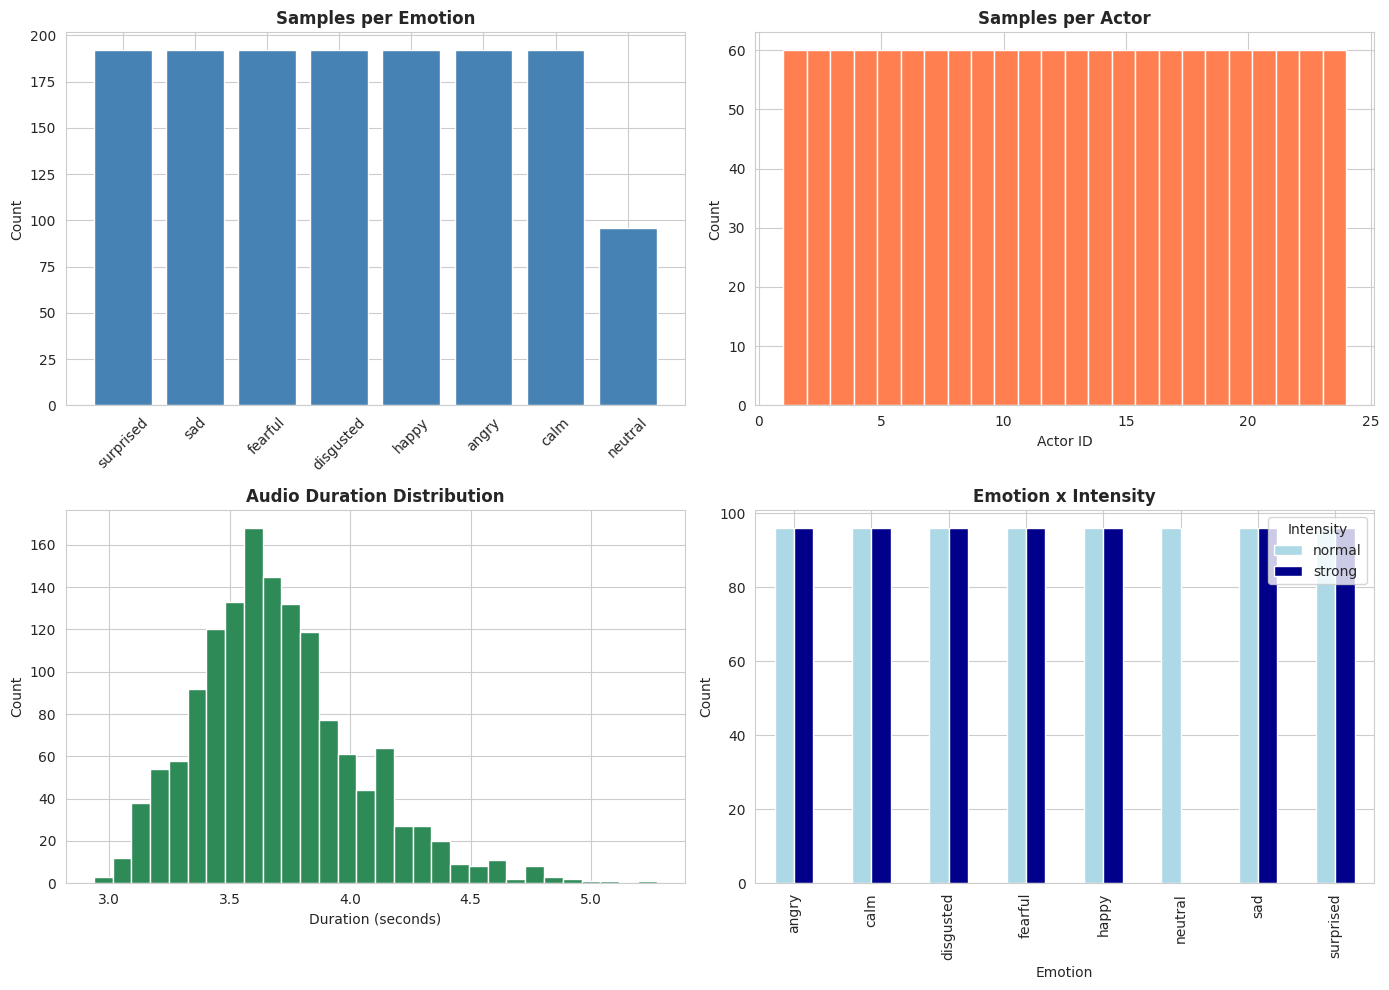

✅ Saved: /content/data_exploration.png


In [9]:
# Dataset statistics
print(f"""
╔════════════════════════════════════════╗
║     RAVDESS DATASET STATISTICS        ║
╚════════════════════════════════════════╝

Total Samples: {len(metadata_df)}
Unique Actors: {metadata_df['actor'].nunique()}
Emotions: {metadata_df['emotion'].nunique()}
Duration Range: {metadata_df['duration'].min():.2f}s - {metadata_df['duration'].max():.2f}s
""")

print("Emotion Distribution:")
print(metadata_df['emotion'].value_counts().sort_index())

print("\nIntensity Distribution:")
print(metadata_df['intensity'].value_counts())

print("\nDuration Statistics:")
print(metadata_df['duration'].describe())

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Emotion distribution
emotion_counts = metadata_df['emotion'].value_counts()
axes[0, 0].bar(range(len(emotion_counts)), emotion_counts.values, color='steelblue')
axes[0, 0].set_xticks(range(len(emotion_counts)))
axes[0, 0].set_xticklabels(emotion_counts.index, rotation=45)
axes[0, 0].set_title('Samples per Emotion', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Actor distribution
axes[0, 1].hist(metadata_df['actor'], bins=24, color='coral')
axes[0, 1].set_title('Samples per Actor', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Actor ID')
axes[0, 1].set_ylabel('Count')

# 3. Duration distribution
axes[1, 0].hist(metadata_df['duration'], bins=30, color='seagreen')
axes[1, 0].set_title('Audio Duration Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Duration (seconds)')
axes[1, 0].set_ylabel('Count')

# 4. Emotion x Intensity
emotion_intensity = metadata_df.groupby(['emotion', 'intensity']).size().unstack(fill_value=0)
emotion_intensity.plot(kind='bar', ax=axes[1, 1], color=['lightblue', 'darkblue'])
axes[1, 1].set_title('Emotion x Intensity', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Emotion')
axes[1, 1].legend(title='Intensity')

plt.tight_layout()
plt.savefig('/content/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/data_exploration.png")

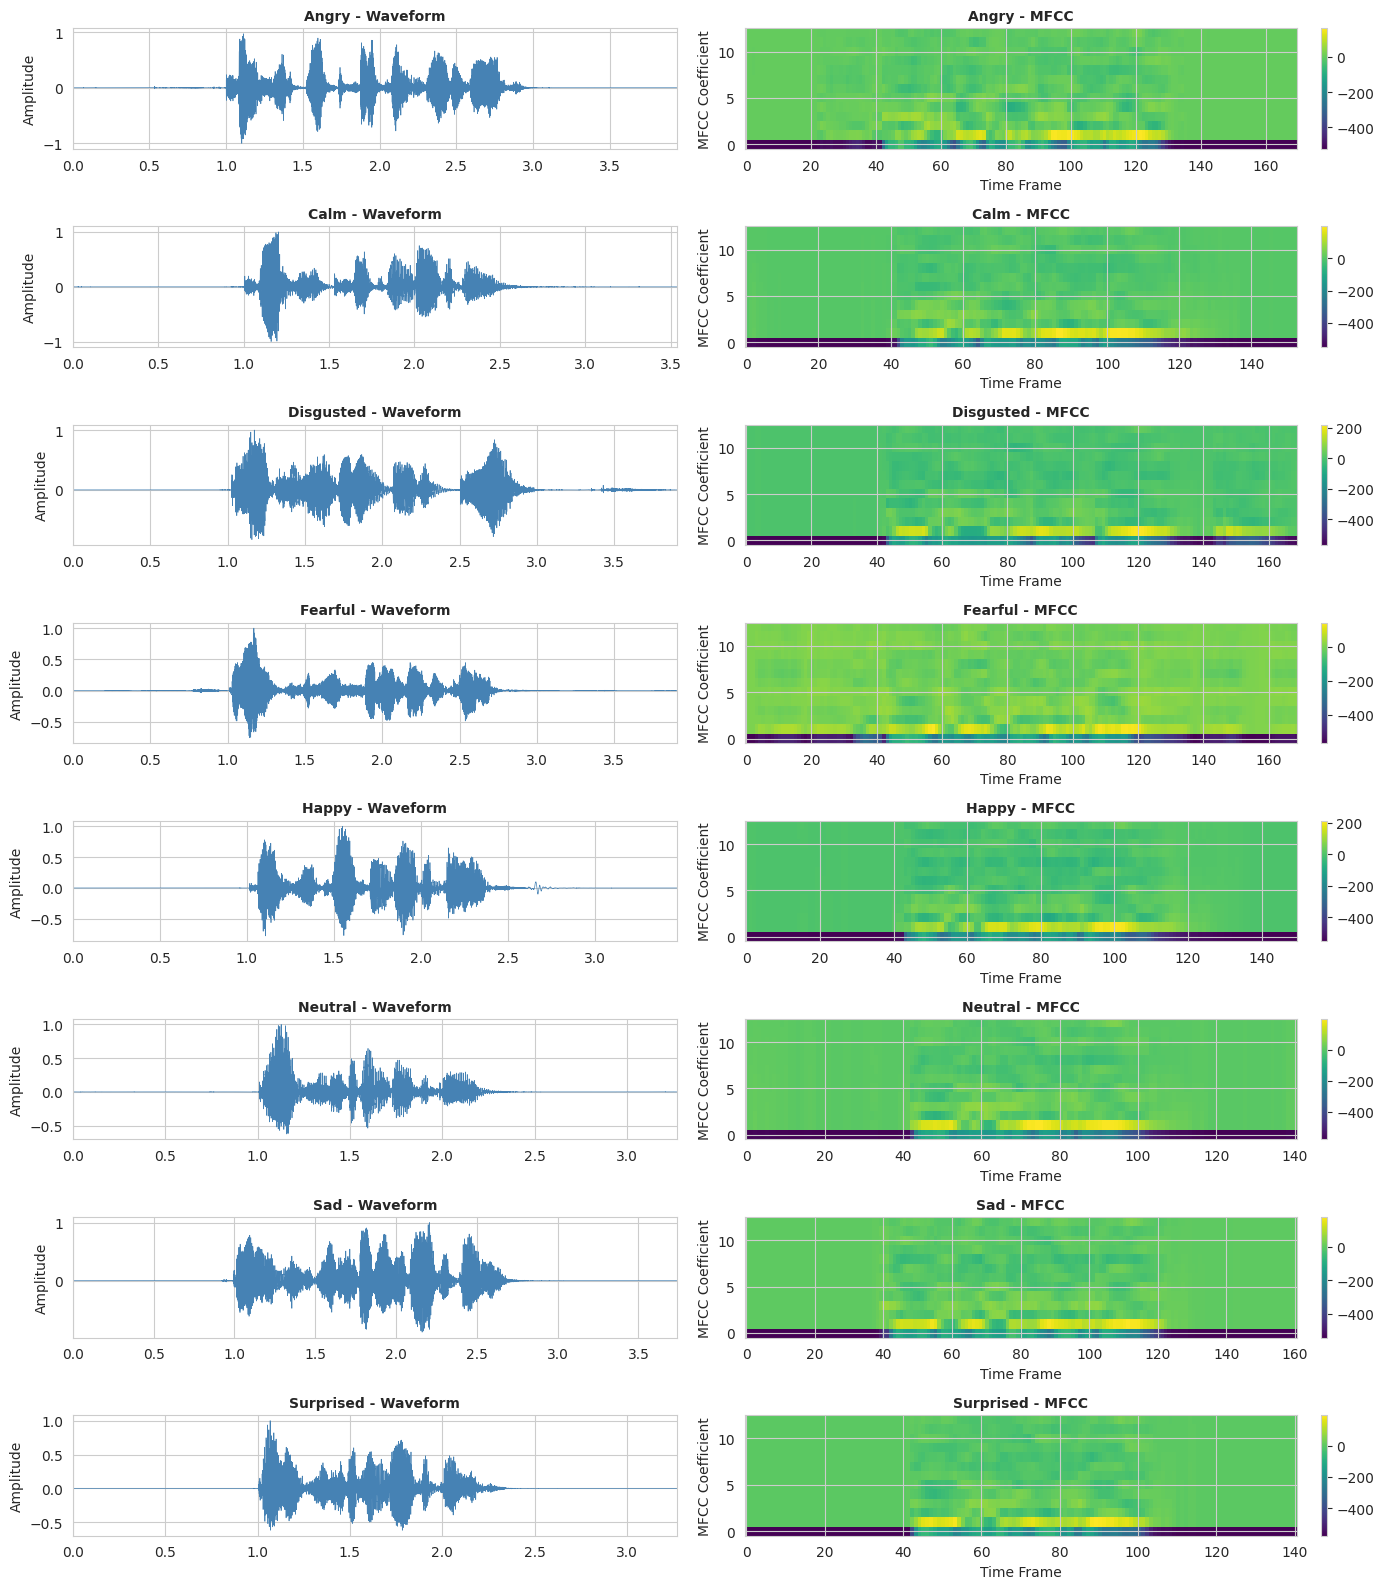

✅ Saved: /content/audio_samples.png


In [11]:
# Visualize sample audio for each emotion
emotions = sorted(metadata_df['emotion'].unique())
fig, axes = plt.subplots(len(emotions), 2, figsize=(14, 2 * len(emotions)))

# Get one sample per emotion

for idx, emotion in enumerate(emotions):
    emotion_sample = metadata_df[metadata_df['emotion'] == emotion].iloc[0]
    audio_path = emotion_sample['path']

    # Load audio
    y, sr = librosa.load(audio_path, sr=22050)
    y = y / (np.max(np.abs(y)) + 1e-8)

    # Waveform
    ax_wave = axes[idx, 0]
    times = np.arange(len(y)) / sr
    ax_wave.plot(times, y, color='steelblue', linewidth=0.5)
    ax_wave.set_title(f'{emotion.capitalize()} - Waveform', fontsize=10, fontweight='bold')
    ax_wave.set_ylabel('Amplitude')
    ax_wave.set_xlim([0, len(y)/sr])

    # Spectrogram (MFCC)
    ax_spec = axes[idx, 1]
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img = ax_spec.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
    ax_spec.set_title(f'{emotion.capitalize()} - MFCC', fontsize=10, fontweight='bold')
    ax_spec.set_ylabel('MFCC Coefficient')
    ax_spec.set_xlabel('Time Frame')
    plt.colorbar(img, ax=ax_spec, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('/content/audio_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/audio_samples.png")

In [12]:
class AudioFeatureExtractor:
    """Extract 50+ DSP features from audio"""

    def __init__(self, sr=22050, n_mfcc=13):
        self.sr = sr
        self.n_mfcc = n_mfcc

    def extract_features(self, audio_path):
        """Extract comprehensive feature set"""
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=self.sr, mono=True)
            y = y / (np.max(np.abs(y)) + 1e-8)

            features = {}

            # 1. MFCC (13 + delta + delta-delta = 39 features)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=self.n_mfcc)
            mfcc_mean = np.mean(mfcc, axis=1)
            mfcc_std = np.std(mfcc, axis=1)
            mfcc_delta = np.mean(librosa.feature.delta(mfcc), axis=1)

            for i in range(self.n_mfcc):
                features[f'mfcc_{i}_mean'] = mfcc_mean[i]
                features[f'mfcc_{i}_std'] = mfcc_std[i]
                features[f'mfcc_{i}_delta'] = mfcc_delta[i]

            # 2. Spectral features
            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
            features['spectral_centroid_mean'] = np.mean(centroid)
            features['spectral_centroid_std'] = np.std(centroid)

            rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
            features['spectral_rolloff_mean'] = np.mean(rolloff)
            features['spectral_rolloff_std'] = np.std(rolloff)

            # 3. Zero Crossing Rate
            zcr = librosa.feature.zero_crossing_rate(y)[0]
            features['zcr_mean'] = np.mean(zcr)
            features['zcr_std'] = np.std(zcr)

            # 4. RMS Energy
            rms = librosa.feature.rms(y=y)[0]
            features['rms_mean'] = np.mean(rms)
            features['rms_std'] = np.std(rms)
            features['rms_max'] = np.max(rms)

            # 5. Spectral Contrast
            contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
            for i in range(contrast.shape[0]):
                features[f'spectral_contrast_{i}'] = np.mean(contrast[i])

            # 6. Chroma features
            chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
            for i in range(chroma.shape[0]):
                features[f'chroma_{i}'] = np.mean(chroma[i])

            # 7. Spectral Flatness
            S = np.abs(librosa.stft(y))
            spectral_flatness = np.mean(librosa.feature.spectral_flatness(S=S))
            features['spectral_flatness'] = spectral_flatness

            # 8. Zero Crossing Density
            features['zero_crossing_density'] = np.mean(librosa.zero_crossings(y))

            # 9. Additional temporal features
            features['duration'] = librosa.get_duration(y=y, sr=sr)
            features['energy_mean'] = np.mean(np.abs(y) ** 2)

            return features

        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
            return None

# Test feature extractor
print("Testing feature extractor...")
extractor = AudioFeatureExtractor(sr=22050, n_mfcc=13)

test_path = metadata_df.iloc[0]['path']
test_features = extractor.extract_features(test_path)

print(f"✅ Extracted {len(test_features)} features")
print(f"\nSample features:")
for k, v in list(test_features.items())[:5]:
    print(f"  {k}: {v:.4f}")

Testing feature extractor...
✅ Extracted 71 features

Sample features:
  mfcc_0_mean: -401.9012
  mfcc_0_std: 204.1260
  mfcc_0_delta: 0.0000
  mfcc_1_mean: 49.2841
  mfcc_1_std: 67.4896


In [13]:
# Extract features for ALL audio files
print("🔄 Extracting features from all audio files...")
print(f"Total files to process: {len(metadata_df)}")
print("Estimated time: 10-15 minutes\n")

all_features = []
failed_files = []

for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Extracting"):
    features = extractor.extract_features(row['path'])

    if features is not None:
        features['file'] = row['file']
        features['emotion'] = row['emotion']
        features['emotion_id'] = row['emotion_id']
        features['actor'] = row['actor']
        features['intensity'] = row['intensity']
        all_features.append(features)
    else:
        failed_files.append(row['file'])

# Create dataframe
features_df = pd.DataFrame(all_features)

print(f"\n✅ Feature extraction complete!")
print(f"Successfully processed: {len(features_df)}")
print(f"Failed: {len(failed_files)}")

# Save features
features_df.to_csv('/content/data/processed/features.csv', index=False)
print(f"✅ Saved features to: /content/data/processed/features.csv")

# Show statistics
print(f"\nFeature DataFrame shape: {features_df.shape}")
print(f"Columns: {features_df.shape[1]}")
print(f"\nFirst few rows:")
print(features_df.iloc[0:2])

🔄 Extracting features from all audio files...
Total files to process: 1440
Estimated time: 10-15 minutes



Extracting: 100%|██████████| 1440/1440 [05:48<00:00,  4.13it/s]



✅ Feature extraction complete!
Successfully processed: 1440
Failed: 0
✅ Saved features to: /content/data/processed/features.csv

Feature DataFrame shape: (1440, 76)
Columns: 76

First few rows:
   mfcc_0_mean  mfcc_0_std  mfcc_0_delta  mfcc_1_mean  mfcc_1_std  \
0  -401.901215  204.125992           0.0    49.284126   67.489632   
1  -348.150757  200.957352           0.0    50.817352   65.640144   

   mfcc_1_delta  mfcc_2_mean  mfcc_2_std  mfcc_2_delta  mfcc_3_mean  ...  \
0           0.0    -1.809937   21.469467           0.0     8.199510  ...   
1           0.0    -4.100937   21.855808           0.0    13.333532  ...   

   chroma_11  spectral_flatness  zero_crossing_density  duration  energy_mean  \
0   0.594477           0.234024               0.361294  3.269932     0.010187   
1   0.492507           0.181033               0.383687  3.737098     0.018025   

                       file    emotion  emotion_id  actor  intensity  
0  03-01-08-01-02-02-01.wav  surprised           8   

Total features extracted: 71

Feature Statistics:
       mfcc_0_mean  mfcc_0_std  mfcc_0_delta  mfcc_1_mean  mfcc_1_std  \
count    1440.0000   1440.0000     1440.0000    1440.0000   1440.0000   
mean     -362.4006    175.3250        0.0436      48.3750     55.6934   
std        29.1941     16.9251        0.2764      15.9117     10.0278   
min      -432.9851    119.1019       -1.4420      -5.3508     21.5702   
25%      -383.2231    164.8599       -0.0053      38.1301     49.6402   
50%      -362.8889    176.1122        0.0017      48.6311     56.3061   
75%      -342.4375    187.2507        0.0451      59.5683     62.5005   
max      -245.3982    223.5985        3.4248      96.5971     82.3686   

       mfcc_1_delta  mfcc_2_mean  mfcc_2_std  mfcc_2_delta  mfcc_3_mean  ...  \
count     1440.0000    1440.0000   1440.0000     1440.0000    1440.0000  ...   
mean         0.0422      -5.1649     27.8337        0.0206       7.6691  ...   
std          0.1381      12.5090      6.6201        

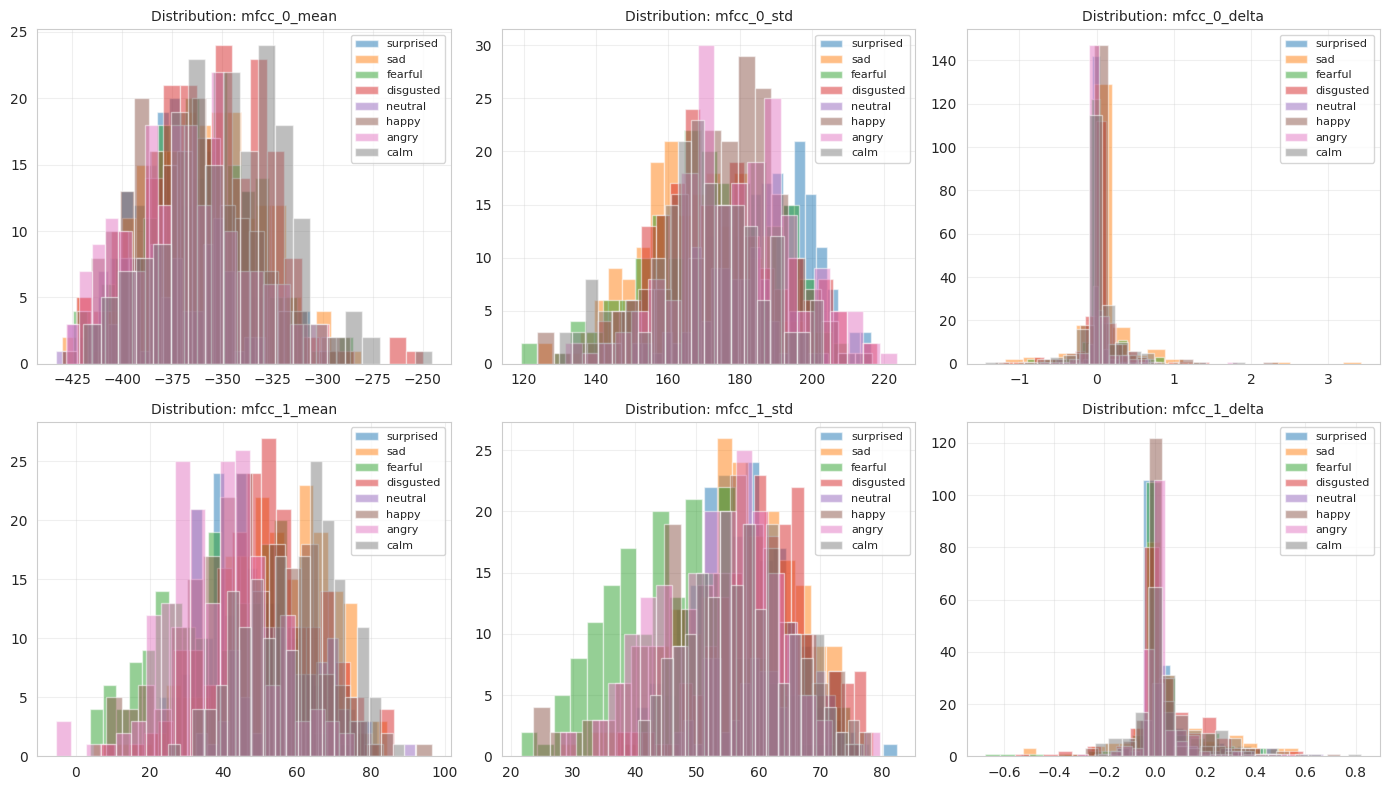

✅ Saved: /content/feature_distributions.png


In [14]:
# Load features if needed
# features_df = pd.read_csv('/content/data/processed/features.csv')

# Get feature columns (exclude metadata)
feature_cols = [c for c in features_df.columns if c not in
               ['file', 'emotion', 'emotion_id', 'actor', 'intensity']]

print(f"Total features extracted: {len(feature_cols)}")

# Feature statistics
print("\nFeature Statistics:")
print(features_df[feature_cols].describe().round(4))

# Check for missing values
missing = features_df[feature_cols].isnull().sum().sum()
print(f"\nMissing values: {missing}")

# Visualize feature distributions for one emotion
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(feature_cols[:6]):
    for emotion in features_df['emotion'].unique():
        emotion_data = features_df[features_df['emotion'] == emotion][col]
        axes[idx].hist(emotion_data, alpha=0.5, label=emotion, bins=20)

    axes[idx].set_title(f'Distribution: {col}', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/feature_distributions.png")

In [15]:
# Get feature columns
feature_cols = [c for c in features_df.columns if c not in
               ['file', 'emotion', 'emotion_id', 'actor', 'intensity']]

X = features_df[feature_cols].values
y = features_df['emotion_id'].values - 1  # 0-indexed

print(f"Data shape: X={X.shape}, y={y.shape}")

# Normalize features (IMPORTANT!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 1: Train/Test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Split 2: Train/Val (70/10)
val_ratio = 0.10 / 0.80
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    stratify=y_temp,
    random_state=42
)

print(f"""
✅ Dataset Split:
─────────────────────────────────
Train: {len(X_train)} samples ({100*len(X_train)/len(X_scaled):.1f}%)
Val:   {len(X_val)} samples ({100*len(X_val)/len(X_scaled):.1f}%)
Test:  {len(X_test)} samples ({100*len(X_test)/len(X_scaled):.1f}%)
─────────────────────────────────
Features per sample: {X_train.shape[1]}

Class Distribution (Train):
{dict(zip(*np.unique(y_train, return_counts=True)))}
""")

# Save splits
data_splits = {
    'X_train': X_train, 'y_train': y_train,
    'X_val': X_val, 'y_val': y_val,
    'X_test': X_test, 'y_test': y_test,
    'feature_names': feature_cols,
    'scaler': scaler,
    'emotions': ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']
}

# Save with joblib for later
import joblib
joblib.dump(data_splits, '/content/data/processed/data_splits.pkl')
print("✅ Saved data splits!")

Data shape: X=(1440, 71), y=(1440,)

✅ Dataset Split:
─────────────────────────────────
Train: 1008 samples (70.0%)
Val:   144 samples (10.0%)
Test:  288 samples (20.0%)
─────────────────────────────────
Features per sample: 71

Class Distribution (Train):
{np.int64(0): np.int64(67), np.int64(1): np.int64(134), np.int64(2): np.int64(135), np.int64(3): np.int64(135), np.int64(4): np.int64(134), np.int64(5): np.int64(134), np.int64(6): np.int64(135), np.int64(7): np.int64(134)}

✅ Saved data splits!


In [16]:
# Build MLP model
def build_mlp_model(input_dim, num_classes=8):
    """Multi-Layer Perceptron"""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        # Layer 1
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Layer 2
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Layer 3
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Build MLP
mlp_model = build_mlp_model(input_dim=X_train.shape[1], num_classes=8)

print("MLP Model Architecture:")
mlp_model.summary()

# Compile
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ MLP model built and compiled!")

MLP Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,704 (803.53 KB)

 Trainable params: 203,912 (796.53 KB)

 Non-trainable params: 1,792 (7.00 KB)

✅ MLP model built and compiled!


In [17]:
# Build 1D CNN model
def build_cnn_1d_model(input_dim, num_classes=8):
    """1D Convolutional Neural Network"""
    model = models.Sequential([
        layers.Input(shape=(input_dim, 1)),

        # Block 1
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),

        # Dense layers
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Reshape data for CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN
cnn_model = build_cnn_1d_model(input_dim=X_train.shape[1], num_classes=8)

print("CNN Model Architecture:")
cnn_model.summary()

# Compile
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ CNN model built and compiled!")

CNN Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 71, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 71, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 71, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 71, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 35, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 35, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 35, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 35, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 17, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 17, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,560 (998.28 KB)

 Trainable params: 254,280 (993.28 KB)

 Non-trainable params: 1,280 (5.00 KB)

✅ CNN model built and compiled!


In [18]:
print("🚀 Training MLP Model...")
print("=" * 60)

# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

# Train
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ MLP training complete!")

# Save model
mlp_model.save('/content/mlp_model.h5')
print("✅ Saved: /content/mlp_model.h5")

🚀 Training MLP Model...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.2480 - loss: 2.4530 - val_accuracy: 0.4167 - val_loss: 1.7483 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4256 - loss: 1.7279 - val_accuracy: 0.4722 - val_loss: 1.5907 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5159 - loss: 1.3302 - val_accuracy: 0.5000 - val_loss: 1.4575 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5546 - loss: 1.2211 - val_accuracy: 0.5486 - val_loss: 1.3341 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6071 - loss: 1.0902 - val_accuracy: 0.5764 - val_loss: 1.2341 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6518 - loss: 0.9299 - val_accuracy: 0.5694 - val_loss: 1.1938 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 


✅ MLP training complete!
✅ Saved: /content/mlp_model.h5


In [19]:
print("🚀 Training CNN Model...")
print("=" * 60)

# Define callbacks
early_stopping_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cnn = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

# Train
history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_cnn, reduce_lr_cnn],
    verbose=1
)

print("\n✅ CNN training complete!")

# Save model
cnn_model.save('/content/cnn_model.h5')
print("✅ Saved: /content/cnn_model.h5")

🚀 Training CNN Model...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.1657 - loss: 2.0886 - val_accuracy: 0.1319 - val_loss: 2.0811 - learning_rate: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.2232 - loss: 1.9884 - val_accuracy: 0.1319 - val_loss: 2.1058 - learning_rate: 0.0010
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2946 - loss: 1.8707 - val_accuracy: 0.1319 - val_loss: 2.1271 - learning_rate: 0.0010
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3036 - loss: 1.8196 - val_accuracy: 0.1250 - val_loss: 2.3065 - learning_rate: 0.0010
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3264 - loss: 1.7666 - val_accuracy: 0.1389 - val_loss: 2.5442 - learning_rate: 0.0010
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3254 - loss: 1.7028 - val_accuracy: 0.1250 - val_loss: 3.1985 - learning_rate: 0.0010
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy:


✅ CNN training complete!
✅ Saved: /content/cnn_model.h5


In [20]:
print("📊 Evaluating MLP Model...")
print("=" * 60)

# Evaluate on test set
mlp_loss, mlp_acc = mlp_model.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred_mlp = np.argmax(mlp_model.predict(X_test, verbose=0), axis=1)

# Metrics
from sklearn.metrics import precision_score, recall_score, f1_score

mlp_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_mlp),
    'f1_macro': f1_score(y_test, y_pred_mlp, average='macro'),
    'f1_weighted': f1_score(y_test, y_pred_mlp, average='weighted'),
    'precision': precision_score(y_test, y_pred_mlp, average='macro'),
    'recall': recall_score(y_test, y_pred_mlp, average='macro'),
}

print(f"""
╔════════════════════════════════════════╗
║        MLP TEST RESULTS               ║
╚════════════════════════════════════════╝

Loss:        {mlp_loss:.4f}
Accuracy:    {mlp_metrics['accuracy']*100:.2f}%
F1 (Macro):  {mlp_metrics['f1_macro']:.4f}
F1 (Weight): {mlp_metrics['f1_weighted']:.4f}
Precision:   {mlp_metrics['precision']:.4f}
Recall:      {mlp_metrics['recall']:.4f}
""")

# Classification report
emotion_names = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgusted', 'surprised']
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=emotion_names))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print(f"Confusion Matrix shape: {cm_mlp.shape}")

📊 Evaluating MLP Model...

╔════════════════════════════════════════╗
║        MLP TEST RESULTS               ║
╚════════════════════════════════════════╝

Loss:        1.0205
Accuracy:    65.62%
F1 (Macro):  0.6434
F1 (Weight): 0.6610
Precision:   0.6475
Recall:      0.6442

Classification Report:
              precision    recall  f1-score   support

     neutral       0.33      0.47      0.39        19
        calm       0.72      0.68      0.70        38
       happy       0.63      0.58      0.60        38
         sad       0.57      0.63      0.60        38
       angry       0.71      0.74      0.72        39
     fearful       0.72      0.67      0.69        39
   disgusted       0.67      0.63      0.65        38
   surprised       0.83      0.74      0.78        39

    accuracy                           0.66       288
   macro avg       0.65      0.64      0.64       288
weighted avg       0.67      0.66      0.66       288

Confusion Matrix shape: (8, 8)


In [21]:
print("📊 Evaluating CNN Model...")
print("=" * 60)

# Evaluate on test set
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

# Predictions
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)

# Metrics
cnn_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_cnn),
    'f1_macro': f1_score(y_test, y_pred_cnn, average='macro'),
    'f1_weighted': f1_score(y_test, y_pred_cnn, average='weighted'),
    'precision': precision_score(y_test, y_pred_cnn, average='macro'),
    'recall': recall_score(y_test, y_pred_cnn, average='macro'),
}

print(f"""
╔════════════════════════════════════════╗
║        CNN TEST RESULTS               ║
╚════════════════════════════════════════╝

Loss:        {cnn_loss:.4f}
Accuracy:    {cnn_metrics['accuracy']*100:.2f}%
F1 (Macro):  {cnn_metrics['f1_macro']:.4f}
F1 (Weight): {cnn_metrics['f1_weighted']:.4f}
Precision:   {cnn_metrics['precision']:.4f}
Recall:      {cnn_metrics['recall']:.4f}
""")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=emotion_names))

# Confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
print(f"Confusion Matrix shape: {cm_cnn.shape}")

📊 Evaluating CNN Model...

╔════════════════════════════════════════╗
║        CNN TEST RESULTS               ║
╚════════════════════════════════════════╝

Loss:        1.6286
Accuracy:    42.36%
F1 (Macro):  0.4148
F1 (Weight): 0.4255
Precision:   0.4433
Recall:      0.4265

Classification Report:
              precision    recall  f1-score   support

     neutral       0.18      0.47      0.26        19
        calm       0.51      0.61      0.55        38
       happy       0.41      0.50      0.45        38
         sad       0.42      0.21      0.28        38
       angry       0.42      0.46      0.44        39
     fearful       0.49      0.44      0.46        39
   disgusted       0.55      0.29      0.38        38
   surprised       0.57      0.44      0.49        39

    accuracy                           0.42       288
   macro avg       0.44      0.43      0.41       288
weighted avg       0.46      0.42      0.43       288

Confusion Matrix shape: (8, 8)


In [22]:
# Compare models
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison_df = pd.DataFrame({
    'Model': ['MLP', 'CNN'],
    'Test Accuracy': [f"{mlp_metrics['accuracy']*100:.2f}%", f"{cnn_metrics['accuracy']*100:.2f}%"],
    'F1 Score': [f"{mlp_metrics['f1_macro']:.4f}", f"{cnn_metrics['f1_macro']:.4f}"],
    'Parameters': [mlp_model.count_params(), cnn_model.count_params()],
    'Model Size (MB)': [
        f"{mlp_model.count_params() * 4 / (1024**2):.2f}",
        f"{cnn_model.count_params() * 4 / (1024**2):.2f}"
    ]
})

print("\n" + comparison_df.to_string(index=False))

# Determine best model
if mlp_metrics['accuracy'] > cnn_metrics['accuracy']:
    print("\n✅ BEST MODEL: MLP")
    best_model = mlp_model
    best_metrics = mlp_metrics
    y_pred_best = y_pred_mlp
else:
    print("\n✅ BEST MODEL: CNN")
    best_model = cnn_model
    best_metrics = cnn_metrics
    y_pred_best = y_pred_cnn

MODEL COMPARISON

Model Test Accuracy F1 Score  Parameters Model Size (MB)
  MLP        65.62%   0.6434      205704            0.78
  CNN        42.36%   0.4148      255560            0.97

✅ BEST MODEL: MLP


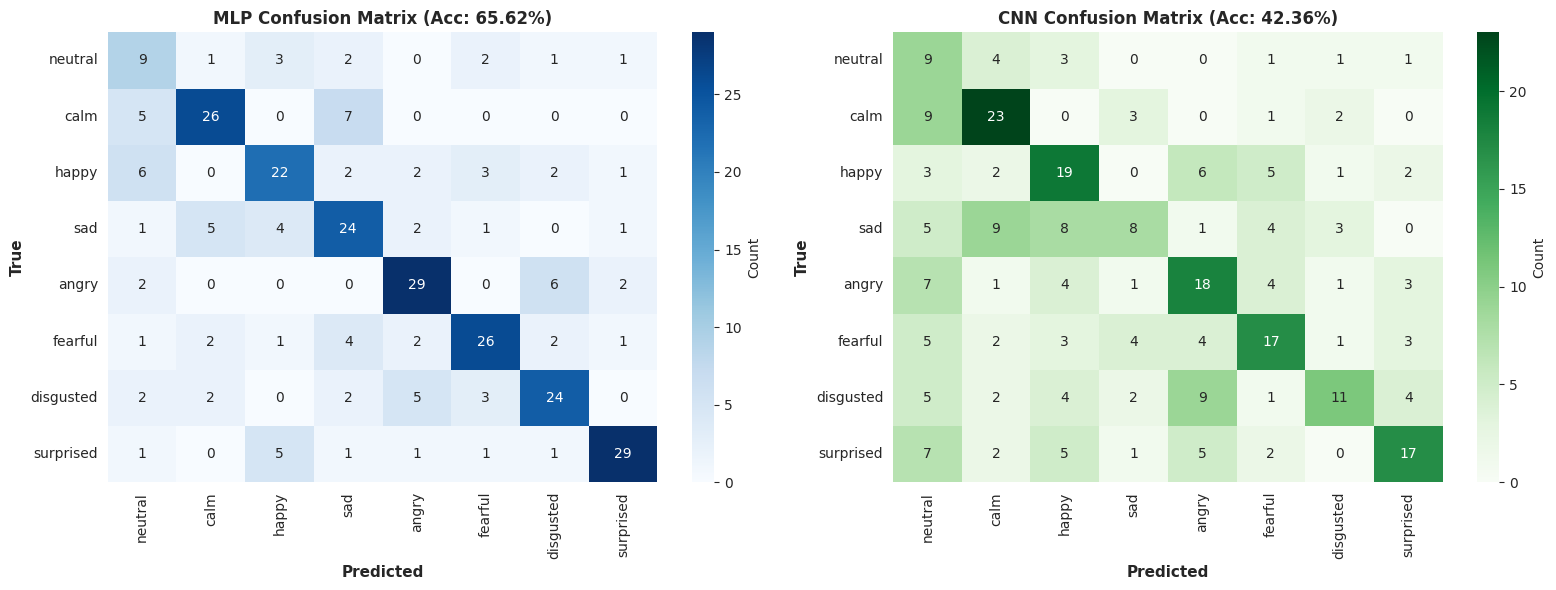

✅ Saved: /content/confusion_matrices.png


In [23]:
# Plot both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MLP Confusion Matrix
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True', fontsize=11, fontweight='bold')
axes[0].set_title(f'MLP Confusion Matrix (Acc: {mlp_metrics["accuracy"]*100:.2f}%)',
                  fontsize=12, fontweight='bold')

# CNN Confusion Matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=emotion_names, yticklabels=emotion_names,
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True', fontsize=11, fontweight='bold')
axes[1].set_title(f'CNN Confusion Matrix (Acc: {cnn_metrics["accuracy"]*100:.2f}%)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/confusion_matrices.png")

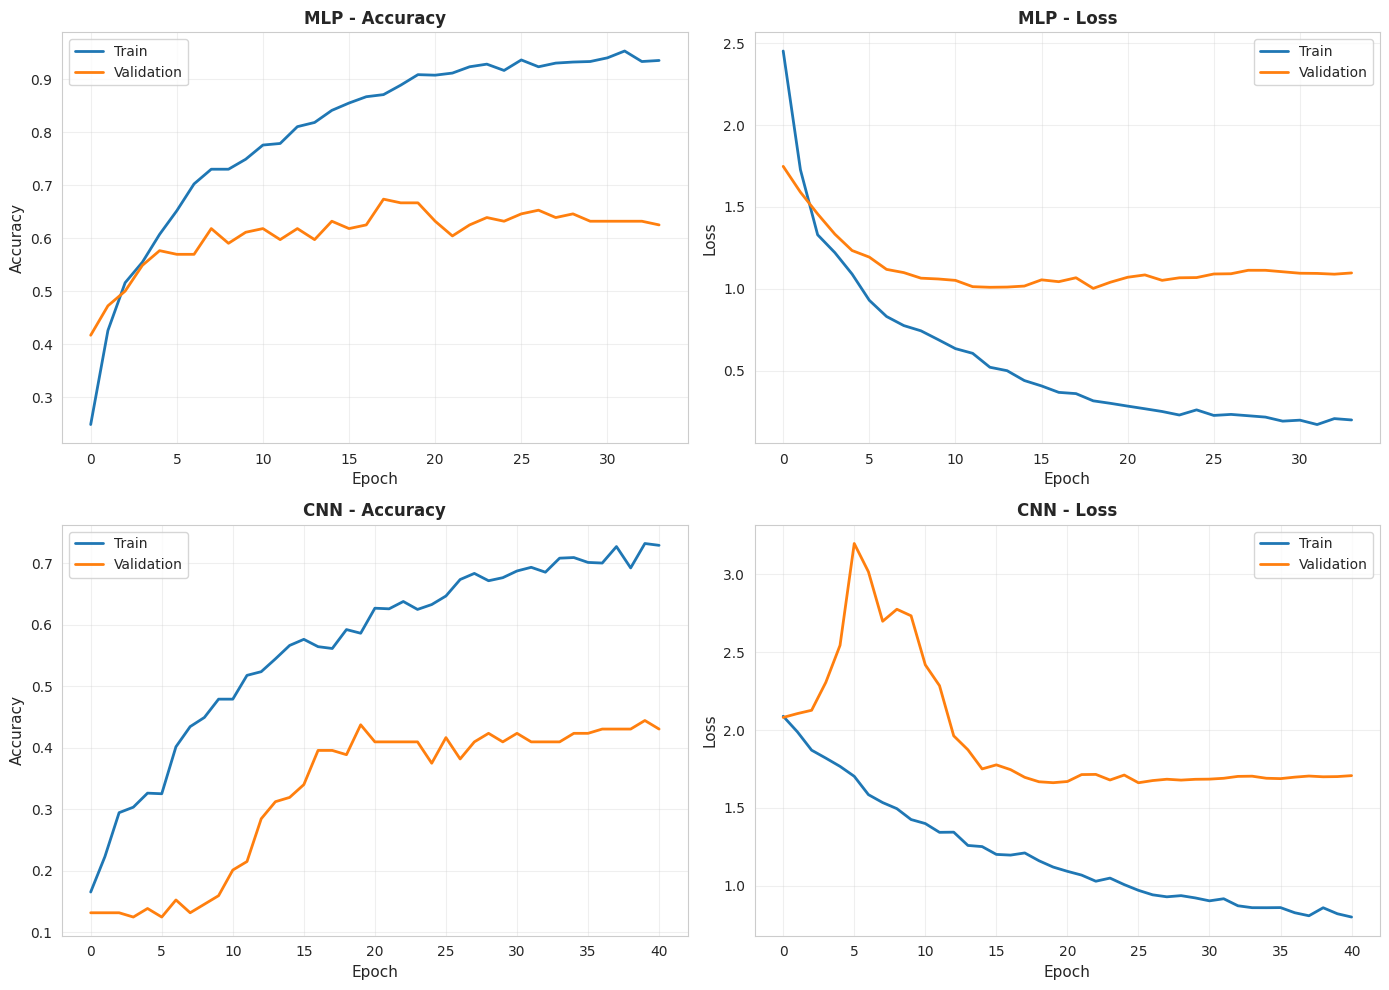

✅ Saved: /content/training_curves.png


In [24]:
# Plot training history for both models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MLP - Accuracy
axes[0, 0].plot(history_mlp.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history_mlp.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('MLP - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MLP - Loss
axes[0, 1].plot(history_mlp.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history_mlp.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('MLP - Loss', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CNN - Accuracy
axes[1, 0].plot(history_cnn.history['accuracy'], label='Train', linewidth=2)
axes[1, 0].plot(history_cnn.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Accuracy', fontsize=11)
axes[1, 0].set_title('CNN - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CNN - Loss
axes[1, 1].plot(history_cnn.history['loss'], label='Train', linewidth=2)
axes[1, 1].plot(history_cnn.history['val_loss'], label='Validation', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Loss', fontsize=11)
axes[1, 1].set_title('CNN - Loss', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/training_curves.png")

Per-Emotion Performance:
  Emotion  Precision   Recall  F1 Score  Support
  neutral   0.333333 0.473684  0.391304       19
     calm   0.722222 0.684211  0.702703       38
    happy   0.628571 0.578947  0.602740       38
      sad   0.571429 0.631579  0.600000       38
    angry   0.707317 0.743590  0.725000       39
  fearful   0.722222 0.666667  0.693333       39
disgusted   0.666667 0.631579  0.648649       38
surprised   0.828571 0.743590  0.783784       39


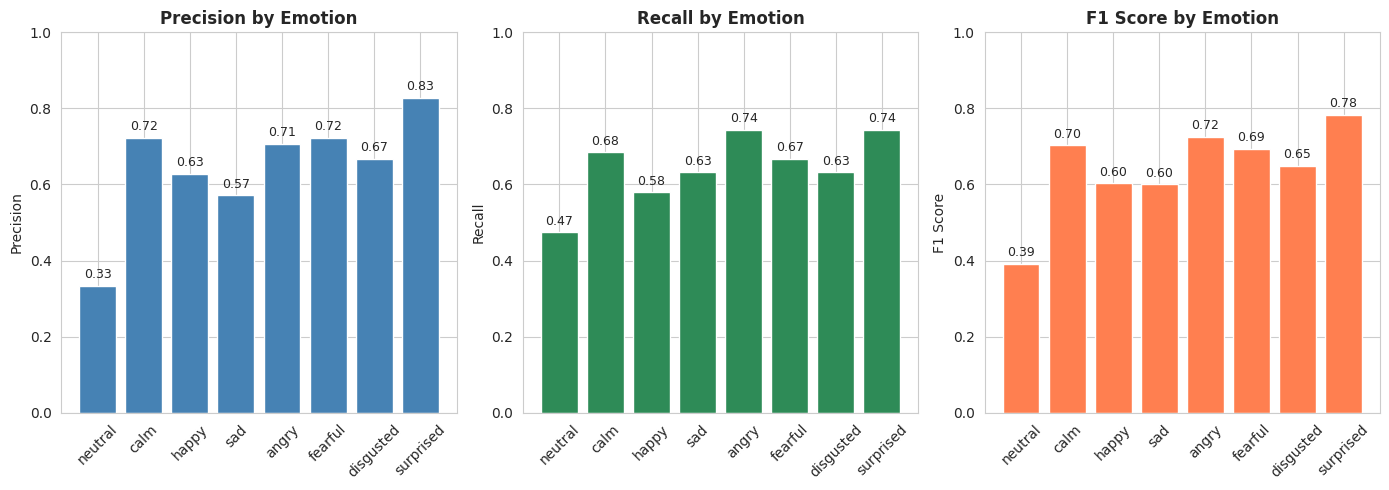

✅ Saved: /content/per_emotion_metrics.png


In [25]:
# Per-emotion metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred_best, average=None
)

emotion_performance = pd.DataFrame({
    'Emotion': emotion_names,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'Support': support
})

print("Per-Emotion Performance:")
print(emotion_performance.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(emotion_names, precision, color='steelblue')
axes[0].set_title('Precision by Emotion', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precision')
axes[0].set_ylim([0, 1])
for i, v in enumerate(precision):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].bar(emotion_names, recall, color='seagreen')
axes[1].set_title('Recall by Emotion', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim([0, 1])
for i, v in enumerate(recall):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

axes[2].bar(emotion_names, f1, color='coral')
axes[2].set_title('F1 Score by Emotion', fontsize=12, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0, 1])
for i, v in enumerate(f1):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('/content/per_emotion_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/per_emotion_metrics.png")

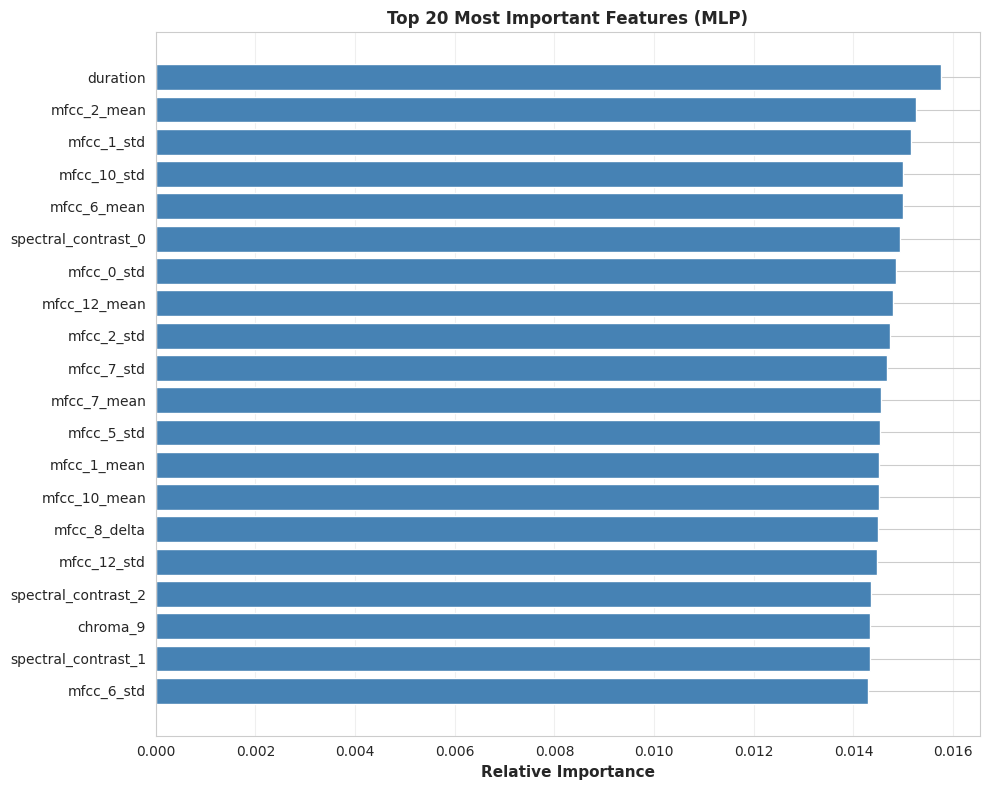

✅ Saved: /content/feature_importance.png

Top 10 Most Important Features:
 1. mfcc_7_std                     :  1.47%
 2. mfcc_2_std                     :  1.47%
 3. mfcc_12_mean                   :  1.48%
 4. mfcc_0_std                     :  1.48%
 5. spectral_contrast_0            :  1.49%
 6. mfcc_6_mean                    :  1.50%
 7. mfcc_10_std                    :  1.50%
 8. mfcc_1_std                     :  1.52%
 9. mfcc_2_mean                    :  1.53%
10. duration                       :  1.58%


In [26]:
# Extract feature importance from MLP's first dense layer
first_layer_weights = mlp_model.layers[0].get_weights()[0]  # (num_features, 512)
feature_importance = np.abs(first_layer_weights).mean(axis=1)
feature_importance = feature_importance / feature_importance.sum()

# Get top 20 features
top_n = 20
top_idx = np.argsort(feature_importance)[-top_n:]
top_features = [data_splits['feature_names'][i] for i in top_idx]
top_importance = feature_importance[top_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_features)), top_importance, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=10)
ax.set_xlabel('Relative Importance', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Most Important Features (MLP)', fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: /content/feature_importance.png")
print("\nTop 10 Most Important Features:")
for i, (feat, imp) in enumerate(zip(top_features[-10:], top_importance[-10:]), 1):
    print(f"{i:2d}. {feat:30s} : {imp*100:5.2f}%")

In [27]:
# Create results summary
results_summary = {
    'MLP Accuracy': f"{mlp_metrics['accuracy']*100:.2f}%",
    'MLP F1 Score': f"{mlp_metrics['f1_macro']:.4f}",
    'CNN Accuracy': f"{cnn_metrics['accuracy']*100:.2f}%",
    'CNN F1 Score': f"{cnn_metrics['f1_macro']:.4f}",
    'Best Model': 'MLP' if mlp_metrics['accuracy'] > cnn_metrics['accuracy'] else 'CNN',
    'Test Set Size': len(y_test),
    'Number of Features': len(data_splits['feature_names']),
    'Number of Classes': 8,
}

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
for k, v in results_summary.items():
    print(f"{k:.<40} {v}")

# Save summary to file
with open('/content/results_summary.txt', 'w') as f:
    f.write("SPEECH EMOTION RECOGNITION - RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    for k, v in results_summary.items():
        f.write(f"{k:.<40} {v}\n")

    f.write("\n\nPER-EMOTION METRICS:\n")
    f.write(emotion_performance.to_string(index=False))

print("\n✅ Saved: /content/results_summary.txt")

# Save all plots and models
print("\n📁 Saved Files:")
print("  - /content/mlp_model.h5")
print("  - /content/cnn_model.h5")
print("  - /content/confusion_matrices.png")
print("  - /content/training_curves.png")
print("  - /content/per_emotion_metrics.png")
print("  - /content/feature_importance.png")
print("  - /content/data_exploration.png")
print("  - /content/audio_samples.png")
print("  - /content/feature_distributions.png")
print("  - /content/results_summary.txt")

FINAL RESULTS SUMMARY
MLP Accuracy............................ 65.62%
MLP F1 Score............................ 0.6434
CNN Accuracy............................ 42.36%
CNN F1 Score............................ 0.4148
Best Model.............................. MLP
Test Set Size........................... 288
Number of Features...................... 71
Number of Classes....................... 8

✅ Saved: /content/results_summary.txt

📁 Saved Files:
  - /content/mlp_model.h5
  - /content/cnn_model.h5
  - /content/confusion_matrices.png
  - /content/training_curves.png
  - /content/per_emotion_metrics.png
  - /content/feature_importance.png
  - /content/data_exploration.png
  - /content/audio_samples.png
  - /content/feature_distributions.png
  - /content/results_summary.txt


In [28]:
def predict_emotion_from_audio(audio_path, model, scaler, feature_names, emotion_names):
    """Predict emotion from any audio file"""

    # Extract features
    features = extractor.extract_features(audio_path)
    if features is None:
        return None

    # Get feature values in correct order
    feature_values = np.array([features[f] for f in feature_names]).reshape(1, -1)

    # Scale
    feature_scaled = scaler.transform(feature_values)

    # Predict
    if model == mlp_model:
        probs = model.predict(feature_scaled, verbose=0)[0]
    else:
        feature_scaled_cnn = feature_scaled.reshape(1, -1, 1)
        probs = model.predict(feature_scaled_cnn, verbose=0)[0]

    emotion_id = np.argmax(probs)
    emotion = emotion_names[emotion_id]
    confidence = probs[emotion_id] * 100

    return {
        'emotion': emotion,
        'confidence': confidence,
        'all_probabilities': {emotion_names[i]: f"{probs[i]*100:.2f}%"
                             for i in range(len(emotion_names))}
    }

# Test on a sample
test_sample = metadata_df.iloc[100]  # Pick a random sample
print(f"Test file: {test_sample['file']}")
print(f"True emotion: {test_sample['emotion']}")

result = predict_emotion_from_audio(
    test_sample['path'],
    best_model,
    data_splits['scaler'],
    data_splits['feature_names'],
    emotion_names
)

print(f"\nPrediction: {result['emotion']}")
print(f"Confidence: {result['confidence']:.2f}%")
print("\nAll probabilities:")
for emotion, prob in result['all_probabilities'].items():
    print(f"  {emotion:.<15} {prob}")

Test file: 03-01-08-02-01-02-02.wav
True emotion: surprised

Prediction: surprised
Confidence: 99.08%

All probabilities:
  neutral........ 0.01%
  calm........... 0.01%
  happy.......... 0.05%
  sad............ 0.01%
  angry.......... 0.80%
  fearful........ 0.03%
  disgusted...... 0.02%
  surprised...... 99.08%


In [29]:
# Prepare all files for download
from google.colab import files

files_to_download = [
    '/content/confusion_matrices.png',
    '/content/training_curves.png',
    '/content/per_emotion_metrics.png',
    '/content/feature_importance.png',
    '/content/data_exploration.png',
    '/content/results_summary.txt'
]

print("📥 Ready to download:")
for f in files_to_download:
    if os.path.exists(f):
        print(f"  ✅ {os.path.basename(f)}")

📥 Ready to download:
  ✅ confusion_matrices.png
  ✅ training_curves.png
  ✅ per_emotion_metrics.png
  ✅ feature_importance.png
  ✅ data_exploration.png
  ✅ results_summary.txt


In [30]:
# If you run out of memory, clear cache
import gc
gc.collect()
tf.keras.backend.clear_session()

In [31]:
# Save models to Drive for permanent storage
import shutil
shutil.copy('/content/mlp_model.h5', '/content/drive/MyDrive/emotion_recognition/models/')
shutil.copy('/content/cnn_model.h5', '/content/drive/MyDrive/emotion_recognition/models/')

'/content/drive/MyDrive/emotion_recognition/models/cnn_model.h5'

In [34]:
# If Colab disconnects, load previously trained models
from tensorflow.keras.models import load_model
mlp_model = load_model('/content/drive/MyDrive/emotion_recognition/models/mlp_model.h5')

# Generate predictions with the loaded MLP model
print("\nGenerating predictions with the loaded MLP model...")
y_pred_loaded_mlp = mlp_model.predict(X_test)
predicted_classes_loaded_mlp = np.argmax(y_pred_loaded_mlp, axis=1)

print("First 5 predictions (0-indexed emotion IDs):")
print(predicted_classes_loaded_mlp[:5])
print("Corresponding true values:")
print(y_test[:5])


Generating predictions with the loaded MLP model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step 
First 5 predictions (0-indexed emotion IDs):
[0 7 7 6 6]
Corresponding true values:
[2 7 7 6 2]
